In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [3]:
# create non-linear dataset.
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.rand(200, 1)

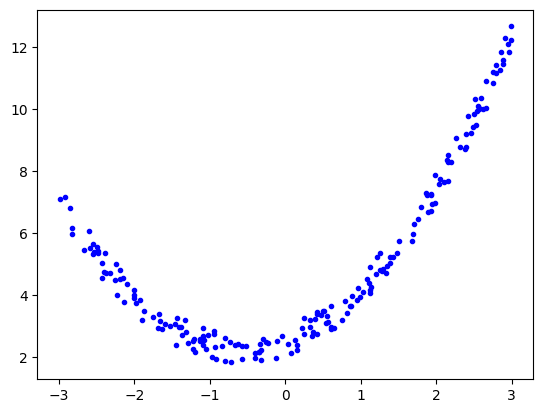

In [4]:
plt.plot(X, y, 'b.')
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [6]:
reg = LinearRegression()
reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
y_pred = reg.predict(X_test)
r2_score(y_test, y_pred)

0.26945775031791275

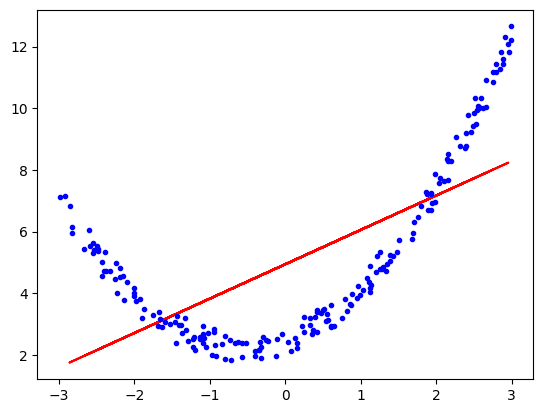

In [9]:
plt.plot(X_test, y_pred, color='r')
plt.plot(X, y, 'b.')
plt.show()

In [34]:
polyReg = PolynomialFeatures(degree=2)

In [35]:
X_train_poly = polyReg.fit_transform(X_train)
X_test_poly = polyReg.transform(X_test)

In [36]:
print(X_train[0])
print(X_train_poly[0])

[-0.26163094]
[ 1.         -0.26163094  0.06845075]


In [37]:
lr = LinearRegression()
lr.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
y_pred_transed = lr.predict(X_test_poly)
r2_score(y_pred_transed, y_test)

0.9891038077454154

In [39]:
lr.coef_ , lr.intercept_

(array([[0.        , 0.87645673, 0.8027428 ]]), array([2.48457972]))

In [40]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = polyReg.transform(X_new)
y_pred_new = lr.predict(X_new_poly)

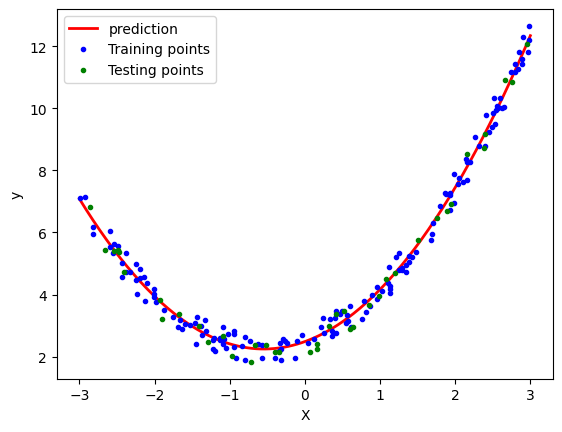

In [44]:
plt.plot(X_new, y_pred_new, 'r-', linewidth=2, label='prediction')
plt.plot(X_train, y_train, 'b.', label='Training points')
plt.plot(X_test, y_test, 'g.', label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()